# SVM + LowVariance — Classificação de Ataques DoS em MQTT

Pipeline dedicado ao SVM com as 12 features selecionadas por Low Variance.
Replica o fluxo de pré-processamento do `03_pipeline_05_05.ipynb`.

## Etapas
1. **Carregamento e limpeza** — remove colunas inúteis do Wireshark
2. **Engenharia de features** — `connect_gap` e `publish_gap`
3. **Seleção LowVariance** — 12 features com maior variância
4. **Split estratificado + Imputação pós-split** — sem data leakage
5. **Escalonamento** — `StandardScaler` (SVM exige)
6. **Baseline SVM** — kernel rbf, C=1.0, gamma=scale
7. **Otimização Optuna — `svm_hold_out`** — 25 trials, validação hold-out *(ativo)*
8. **Otimização Optuna — `svm_2_fold`** — 50 trials, 2-fold CV *(comentado, opcional)*
9. **Modelo final** — métricas completas, matriz de confusão, curva ROC
10. **Salvar artefatos** — modelo, scaler, datasets, relatórios

## Artefatos gerados

| Categoria | Caminho | Descrição |
|---|---|---|
| Modelo | `models/models_ensemble_v2/svm/best_svm_lowvariance.pkl` | SVM otimizado |
| Scaler | `models/models_ensemble_v2/svm/scaler.pkl` | `StandardScaler` fitado |
| Info | `models/models_ensemble_v2/svm/model_info.json` | Parâmetros e métricas |
| Dataset completo | `data/processed/feature_sets/lowvariance_complete.csv` | 12 ft + `type`, 94.625 linhas |
| Dataset treino | `data/processed/feature_sets/lowvariance_train_raw.csv` | Split treino (75.700) |
| Dataset teste | `data/processed/feature_sets/lowvariance_test_raw.csv` | Split teste (18.925) |
| Métricas | `reports/reports_ensemble_v2/svm_results.csv` | Baseline x Otimizado |
| Matriz de confusão | `reports/reports_ensemble_v2/svm_confusion_matrix.png` | Heatmap |
| Curva ROC | `reports/reports_ensemble_v2/svm_roc_curve.png` | AUC |
| Histórico Optuna | `reports/reports_ensemble_v2/svm_optuna_history.png` | Evolução do F1 |

In [1]:
# Configuracao inicial
import json
import joblib
from pathlib import Path
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score,
)

import optuna
from optuna.samplers import TPESampler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LOWVARIANCE_FEATURES = [
    'frame.time_delta', 'frame.cap_len', 'frame.len',
    'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.kalive',
    'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.topic_len',
    'publish_gap', 'connect_gap',
]

DATA_RAW = Path('../data/raw/MQTT Under Attack Dataset/DoS.csv')
DATA_PROCESSED = Path('../data/processed/feature_sets')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path('../models/models_ensemble_v2/svm')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = Path('../reports/reports_ensemble_v2')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

API_INFERENCE_DIR = Path('../api_inference')
API_MODELS_DIR = API_INFERENCE_DIR / 'models'
API_DATASETS_TEST_DIR = API_INFERENCE_DIR / 'datasets' / 'test'
API_MODELS_DIR.mkdir(parents=True, exist_ok=True)
API_DATASETS_TEST_DIR.mkdir(parents=True, exist_ok=True)
API_MODEL_NAME = 'optuna_by_selector_lowvariance_svm'

timing_records = []
TIMING_DEFAULTS = {
    'stage': None, 'modelo': None, 'status': 'success',
    'n_features': np.nan, 'n_trials': np.nan,
    'tempo_fit_sec': np.nan, 'tempo_predict_sec': np.nan,
    'tempo_proba_sec': np.nan, 'tempo_total_sec': np.nan,
    'tempo_otimizacao_sec': np.nan,
    'experiment_timestamp': None,
}

def append_timing(stage, **payload):
    record = TIMING_DEFAULTS.copy()
    record['stage'] = stage
    record['experiment_timestamp'] = pd.Timestamp.now().isoformat()
    record.update(payload)
    timing_records.append(record)
    return record

print('OK: ambiente configurado')
print(f'Features LowVariance ({len(LOWVARIANCE_FEATURES)}): {LOWVARIANCE_FEATURES}')
print(f'Modelos:    {MODELS_DIR}')
print(f'Reports:    {REPORTS_DIR}')
print(f'Datasets:   {DATA_PROCESSED}')

OK: ambiente configurado
Features LowVariance (12): ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
Modelos:    ../models/models_ensemble_v2/svm
Reports:    ../reports/reports_ensemble_v2
Datasets:   ../data/processed/feature_sets


## 1. Carregamento, Limpeza e Engenharia de Features

Remove colunas inúteis do Wireshark e cria `publish_gap` e `connect_gap`.

Origem: `data/raw/MQTT Under Attack Dataset/DoS.csv`

In [2]:
# Carregar dados brutos
df = pd.read_csv(DATA_RAW)
print(f'Dataset shape: {df.shape}')

columns_to_remove = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid',
    'frame.time_relative', 'frame.coloring_rule.name', 'frame.coloring_rule.string',
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 'frame.file_off',
    'frame.ignored', 'frame.incomplete', 'frame.interface_id', 'frame.interface_name',
    'frame.link_nr', 'frame.marked', 'frame.md5_hash', 'frame.number',
    'frame.offset_shift',
    'ip.src', 'ip.dst', 'eth.src', 'eth.dst',
    'tcp.srcport', 'tcp.dstport',
    'mqtt.clientid', 'mqtt.conack.flags', 'mqtt.conflags', 'mqtt.dupflag',
    'mqtt.hdrflags', 'mqtt.msg', 'mqtt.msgid', 'mqtt.passwd', 'mqtt.passwd_len',
    'mqtt.proto_len', 'mqtt.protoname', 'mqtt.sub.qos', 'mqtt.suback.qos',
    'mqtt.topic', 'mqtt.username', 'mqtt.username_len', 'mqtt.ver',
    'mqtt.willmsg', 'mqtt.willmsg_len', 'mqtt.willtopic', 'mqtt.willtopic_len',
]
existing_cols = [c for c in columns_to_remove if c in df.columns]
df_clean = df.drop(columns=existing_cols)
print(f'Colunas removidas: {len(existing_cols)}')
print(f'Colunas restantes: {len(df_clean.columns)}')

# Calcular gaps
df_full = pd.read_csv(DATA_RAW)
df_full = df_full.sort_values('frame.time_epoch').reset_index(drop=True)
df_full['publish_gap'] = 0.0
df_full['connect_gap'] = 0.0

for traffic_type in df_full['type'].unique():
    mask = df_full['type'] == traffic_type
    subset = df_full[mask].copy()
    if len(subset) > 1:
        ts = subset['frame.time_epoch'].values
        mt = subset['mqtt.msgtype'].fillna(0).values

        pub_idx = np.where(mt == 3)[0]
        if len(pub_idx) > 1:
            gaps = np.diff(ts[pub_idx])
            for i, idx in enumerate(pub_idx[1:], 1):
                df_full.loc[subset.index[idx], 'publish_gap'] = gaps[i - 1]

        con_idx = np.where(mt == 1)[0]
        if len(con_idx) > 1:
            gaps = np.diff(ts[con_idx])
            for i, idx in enumerate(con_idx[1:], 1):
                df_full.loc[subset.index[idx], 'connect_gap'] = gaps[i - 1]

df_clean['publish_gap'] = df_full['publish_gap'].values
df_clean['connect_gap'] = df_full['connect_gap'].values

print(f'Features adicionadas: publish_gap, connect_gap')
print(f'Publish gap nao-zero: {(df_clean["publish_gap"] != 0).sum()}')
print(f'Connect gap nao-zero: {(df_clean["connect_gap"] != 0).sum()}')

print(f'Shape final: {df_clean.shape}')
print(f'Colunas: {df_clean.columns.tolist()}')
print(f'Distribuicao type:')
print(df_clean['type'].value_counts())

Dataset shape: (94625, 67)
Colunas removidas: 46
Colunas restantes: 21
Features adicionadas: publish_gap, connect_gap
Publish gap nao-zero: 6150
Connect gap nao-zero: 321
Shape final: (94625, 23)
Colunas: ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.retain', 'mqtt.topic_len', 'type', 'publish_gap', 'connect_gap']
Distribuicao type:
type
normal    49111
DoS       45514
Name: count, dtype: int64


## 2. Selecao LowVariance

Filtra apenas as 12 features identificadas como de baixa variancia no `03_pipeline_05_05.ipynb`.

In [3]:
# Aplicar selecao LowVariance
X_full = df_clean.drop('type', axis=1)
y_full = df_clean['type']

X_lv = X_full[LOWVARIANCE_FEATURES]

print(f'Features selecionadas: {len(LOWVARIANCE_FEATURES)}')
print(f'Nomes: {LOWVARIANCE_FEATURES}')
print(f'Shape: {X_lv.shape}')

print(f'\nEstatisticas descritivas das features selecionadas:')
print(X_lv.describe().to_string())

Features selecionadas: 12
Nomes: ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
Shape: (94625, 12)

Estatisticas descritivas das features selecionadas:
       frame.time_delta  frame.cap_len     frame.len  mqtt.clientid_len  mqtt.conack.val  mqtt.kalive      mqtt.len  mqtt.msgtype      mqtt.qos  mqtt.topic_len   publish_gap   connect_gap
count      94625.000000   94625.000000  94625.000000         323.000000       770.000000   323.000000  39535.000000  39535.000000  38464.000000    38468.000000  94625.000000  94625.000000
mean           0.012070     972.513828    972.513828          36.547988        49.579221    57.910217    157.806399      3.110864      0.029586      409.030207      0.015476      0.008903
std            0.144073     663.725442    663.725442           3.975080        47.368045     9.484279     29.595162      1.094848      0.

## 3. Split + Imputacao + Salvar Datasets

Split estratificado 80/20, imputacao com 0 **apos** o split (sem data leakage).

Datasets salvos:
- `data/processed/feature_sets/lowvariance_complete.csv` — 94.625 linhas, imputado
- `data/processed/feature_sets/lowvariance_train_raw.csv` — treino (75.700)
- `data/processed/feature_sets/lowvariance_test_raw.csv` — teste (18.925)

> Todos os CSVs contem as 12 features + coluna `type`. Valores imputados com 0, **nao escalados**.

In [4]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_lv, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

print(f'Split realizado:')
print(f'  Treino: {X_train.shape[0]} amostras')
print(f'  Teste:  {X_test.shape[0]} amostras')
print(f'\nDistribuicao treino:')
print(y_train.value_counts())
print(f'\nDistribuicao teste:')
print(y_test.value_counts())

nulos_treino = X_train.isnull().sum().sum()
nulos_teste = X_test.isnull().sum().sum()
print(f'\nNulos antes da imputacao: treino={nulos_treino}, teste={nulos_teste}')

# Imputacao pos-split
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

# Reconstruir datasets com target
train_df_out = X_train_imp.copy()
train_df_out['type'] = y_train.values

test_df_out = X_test_imp.copy()
test_df_out['type'] = y_test.values

complete_df_out = pd.concat([train_df_out, test_df_out], axis=0)

# Salvar
train_df_out.to_csv(DATA_PROCESSED / 'lowvariance_train_raw.csv', index=False)
test_df_out.to_csv(DATA_PROCESSED / 'lowvariance_test_raw.csv', index=False)
complete_df_out.to_csv(DATA_PROCESSED / 'lowvariance_complete.csv', index=False)

nulos_pos = X_train_imp.isnull().sum().sum()
print(f'Nulos apos imputacao: {nulos_pos}')
print(f'Datasets salvos:')
print(f'  Completo: {DATA_PROCESSED / "lowvariance_complete.csv"}')
print(f'  Treino:   {DATA_PROCESSED / "lowvariance_train_raw.csv"}')
print(f'  Teste:    {DATA_PROCESSED / "lowvariance_test_raw.csv"}')
print(f'  --> 12 features + type, valores imputados com 0, NAO escalados')

Split realizado:
  Treino: 75700 amostras
  Teste:  18925 amostras

Distribuicao treino:
type
normal    39289
DoS       36411
Name: count, dtype: int64

Distribuicao teste:
type
normal    9822
DoS       9103
Name: count, dtype: int64

Nulos antes da imputacao: treino=403865, teste=101092
Nulos apos imputacao: 0
Datasets salvos:
  Completo: ../data/processed/feature_sets/lowvariance_complete.csv
  Treino:   ../data/processed/feature_sets/lowvariance_train_raw.csv
  Teste:    ../data/processed/feature_sets/lowvariance_test_raw.csv
  --> 12 features + type, valores imputados com 0, NAO escalados


## 4. Escalonamento (StandardScaler)

SVM e sensivel a escala — aplicamos `StandardScaler` ajustado no treino.

Scaler salvo em: `models/models_ensemble_v2/svm/scaler.pkl`

In [5]:
# Escalonamento
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns, index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns, index=X_test_imp.index
)

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

print('Dados normalizados (media=0, variancia=1)')
print(f'Scaler salvo em: {MODELS_DIR / "scaler.pkl"}')
print(f'\nMedias do escalonamento: {scaler.mean_}')
print(f'Desvios padrao:          {scaler.scale_}')

Dados normalizados (media=0, variancia=1)
Scaler salvo em: ../models/models_ensemble_v2/svm/scaler.pkl

Medias do escalonamento: [1.21018802e-02 9.73752232e+02 9.73752232e+02 1.20356671e-01
 3.92642008e-01 1.90224571e-01 6.60310964e+01 1.30085865e+00
 1.22324967e-02 1.68328798e+02 1.46763127e-02 7.41828240e-03]
Desvios padrao:          [1.43677383e-01 6.63070590e+02 6.63070590e+02 2.10699417e+00
 6.13762300e+00 3.35712489e+00 8.01816024e+01 1.68966453e+00
 1.72963627e-01 1.63729128e+03 1.35345895e+00 1.30293937e+00]


## 5. Funcao de Avaliacao

Helper reutilizavel para baseline e modelo final.

In [6]:
def evaluate_svm(model, X_test, y_test, compute_proba=True):
    '''Avalia modelo SVM e retorna metricas + tempos.'''
    predict_start = time.perf_counter()
    y_pred = model.predict(X_test)
    tempo_predict = time.perf_counter() - predict_start

    if compute_proba and hasattr(model, 'predict_proba'):
        proba_start = time.perf_counter()
        try:
            y_prob = model.predict_proba(X_test)
            tempo_proba = time.perf_counter() - proba_start
        except Exception:
            y_prob = None
            tempo_proba = 0.0
    else:
        y_prob = None
        tempo_proba = 0.0

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

    if y_prob is not None:
        metrics['log_loss'] = log_loss(y_test, y_prob, labels=sorted(y_test.unique()))
    else:
        metrics['log_loss'] = np.nan

    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)

    return {
        'metrics': metrics,
        'predictions': y_pred,
        'probabilities': y_prob,
        'confusion_matrix': cm,
        'fp_per_class': fp.tolist(),
        'fn_per_class': fn.tolist(),
        'tempo_predict_sec': tempo_predict,
        'tempo_proba_sec': tempo_proba,
        'tempo_total_sec': tempo_predict + tempo_proba,
    }

print('evaluate_svm() pronta')

evaluate_svm() pronta


## 6. SVM Baseline

`SVC(kernel='rbf', C=1.0, gamma='scale')` — parametros padrao do scikit-learn.

In [7]:
# SVM baseline
svm_baseline = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, random_state=RANDOM_STATE
)

fit_start = time.perf_counter()
svm_baseline.fit(X_train_scaled, y_train)
tempo_fit = time.perf_counter() - fit_start

result_base = evaluate_svm(svm_baseline, X_test_scaled, y_test, compute_proba=True)
m = result_base['metrics']

append_timing('baseline', modelo='SVM', n_features=len(LOWVARIANCE_FEATURES),
              tempo_fit_sec=tempo_fit, tempo_total_sec=tempo_fit + result_base['tempo_total_sec'])

print('=' * 60)
print('SVM BASELINE (kernel=rbf, C=1.0, gamma=scale)')
print('=' * 60)
print(f'  Accuracy:  {m["accuracy"]:.4f}')
print(f'  Precision: {m["precision"]:.4f}')
print(f'  Recall:    {m["recall"]:.4f}')
print(f'  F1 Score:  {m["f1"]:.4f}')
print(f'  Log Loss:  {m["log_loss"]:.4f}')
print(f'  FP: {result_base["fp_per_class"]}')
print(f'  FN: {result_base["fn_per_class"]}')
print(f'  Fit: {tempo_fit:.4f}s | Predict: {result_base["tempo_predict_sec"]:.4f}s')
print(classification_report(y_test, result_base['predictions']))

SVM BASELINE (kernel=rbf, C=1.0, gamma=scale)
  Accuracy:  0.9278
  Precision: 0.9359
  Recall:    0.9278
  F1 Score:  0.9273
  Log Loss:  0.2226
  FP: [27, 1339]
  FN: [1339, 27]
  Fit: 123.3302s | Predict: 4.0565s
              precision    recall  f1-score   support

         DoS       1.00      0.85      0.92      9103
      normal       0.88      1.00      0.93      9822

    accuracy                           0.93     18925
   macro avg       0.94      0.93      0.93     18925
weighted avg       0.94      0.93      0.93     18925



## 7. Optuna — `svm_hold_out`

Busca rapida com 25 trials e validacao hold-out (80/20).
Usa `decision_function` (sem Platt scaling) para acelerar.

> Estimativa: ~2-8 minutos (dependendo do hardware).

Historico salvo em: `reports/reports_ensemble_v2/svm_optuna_history.png`

[I 2026-06-18 11:15:24,410] A new study created in memory with name: svm_lowvariance_holdout


Sub-split: treino=60560, validacao=15140
Trials: 12


Best trial: 2. Best value: 0.930333:   8%|▊         | 1/12 [00:57<10:28, 57.14s/it]

[I 2026-06-18 11:16:21,550] Trial 2 finished with value: 0.9303333750811715 and parameters: {'C': 3.836519337616777, 'gamma': 0.5304456376446945}. Best is trial 2 with value: 0.9303333750811715.


Best trial: 2. Best value: 0.930333:  17%|█▋        | 2/12 [01:03<04:35, 27.56s/it]

...

[I 2026-06-18 11:16:51,441] Trial 11 finished with value: 0.9251291739905083 and parameters: {'C': 39.83307813462763, 'gamma': 0.00021137668316105983}. Best is trial 2 with value: 0.9303333750811715.


Best trial: 2. Best value: 0.930333:  92%|█████████▏| 11/12 [01:28<00:02,  2.01s/it]

[I 2026-06-18 11:16:52,726] Trial 10 finished with value: 0.9248026490499403 and parameters: {'C': 0.019838735729484743, 'gamma': 0.005811538547489913}. Best is trial 2 with value: 0.9303333750811715.


Best trial: 2. Best value: 0.930333: 100%|██████████| 12/12 [01:32<00:00,  7.69s/it]

[I 2026-06-18 11:16:56,657] Trial 3 finished with value: 0.9302643789416692 and parameters: {'C': 16.2684547645368, 'gamma': 0.6535454794942729}. Best is trial 2 with value: 0.9303333750811715.

Otimizacao concluida em 92.25s (12 trials)
Melhor F1 (validacao): 0.9303

Melhores parametros:
  C: 3.836519337616777
  gamma: 0.5304456376446945


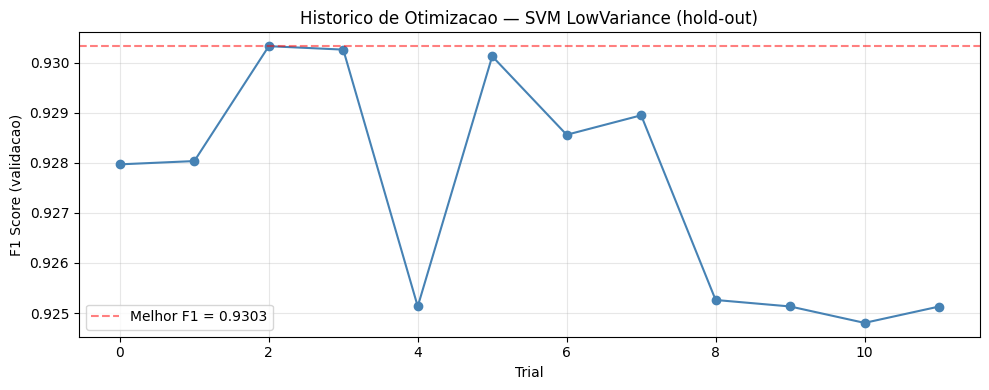

Grafico salvo em: ../reports/reports_ensemble_v2/svm_optuna_history.png


In [8]:
N_TRIALS_FAST = 12
VAL_SIZE = 0.2

# Sub-split para validacao hold-out
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

print(f'Sub-split: treino={X_tr.shape[0]}, validacao={X_val.shape[0]}')
print(f'Trials: {N_TRIALS_FAST}')

def objective_holdout(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e3, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 10, log=True),
        'kernel': 'rbf',
        'random_state': RANDOM_STATE,
        'probability': False,
    }
    model = SVC(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='weighted')

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='svm_lowvariance_holdout',
)

opt_start = time.perf_counter()
study.optimize(objective_holdout, n_trials=N_TRIALS_FAST, n_jobs=-1, show_progress_bar=True)
opt_elapsed = time.perf_counter() - opt_start

append_timing('optuna_holdout', modelo='SVM',
              n_trials=N_TRIALS_FAST, tempo_otimizacao_sec=opt_elapsed)

best_params = study.best_params.copy()

print(f'\nOtimizacao concluida em {opt_elapsed:.2f}s ({N_TRIALS_FAST} trials)')
print(f'Melhor F1 (validacao): {study.best_value:.4f}')
print(f'\nMelhores parametros:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Plot do historico
trials_df = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_df['number'], trials_df['value'], 'o-', color='steelblue')
ax.axhline(study.best_value, color='red', linestyle='--', alpha=0.5,
           label=f'Melhor F1 = {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('F1 Score (validacao)')
ax.set_title('Historico de Otimizacao — SVM LowVariance (hold-out)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svm_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafico salvo em: {REPORTS_DIR / "svm_optuna_history.png"}')

## 8. Alternativa Robusta — `svm_2_fold` (comentada)

Para ativar, descomente toda a celula abaixo e comente a celula **"Optuna — svm_hold_out"** acima.

| Caracteristica | `svm_hold_out` (ativo) | `svm_2_fold` (comentado) |
|---|---|---|
| Validacao | Hold-out 80/20 | StratifiedKFold 2-fold |
| Trials | 25 | 50 |
| Tempo estimado | ~2-8 min | ~1-4 horas |
| Robustez | Boa para exploracao | Melhor para producao |

In [9]:
# ================================================================
#  svm_2_fold: versao robusta com Cross-Validation (2 folds)
# ================================================================
#
# Para ativar:
#   1. Comente a celula "Optuna -- svm_hold_out" acima
#   2. Descomente esta celula (selecione tudo e Ctrl+/)
#   3. Reexecute o notebook
#
# Diferencas:
#   - StratifiedKFold(n_splits=2) em vez de hold-out 80/20
#   - 50 trials em vez de 25
#   - ~50x mais lento, mas estimativas mais estaveis

# from sklearn.model_selection import StratifiedKFold
#
# N_TRIALS_ROBUST = 50
#
# def objective_2fold(trial):
#     kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
#     params = {
#         'C': trial.suggest_float('C', 1e-2, 1e3, log=True),
#         'gamma': trial.suggest_float('gamma', 1e-4, 10, log=True),
#         'kernel': kernel,
#         'random_state': RANDOM_STATE,
#         'probability': False,
#     }
#     if kernel == 'poly':
#         params['degree'] = trial.suggest_int('degree', 2, 5)
#         params['coef0'] = trial.suggest_float('coef0', -1.0, 1.0)
#     elif kernel == 'sigmoid':
#         params['coef0'] = trial.suggest_float('coef0', -1.0, 1.0)
#
#     skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
#     scores = []
#
#     for train_idx, val_idx in skf.split(X_train_scaled, y_train):
#         X_fold_train = X_train_scaled.iloc[train_idx]
#         X_fold_val   = X_train_scaled.iloc[val_idx]
#         y_fold_train = y_train.iloc[train_idx]
#         y_fold_val   = y_train.iloc[val_idx]
#
#         model = SVC(**params)
#         model.fit(X_fold_train, y_fold_train)
#         y_pred = model.predict(X_fold_val)
#         scores.append(f1_score(y_fold_val, y_pred, average='weighted'))
#
#     return np.mean(scores)
#
# study_robust = optuna.create_study(
#     direction='maximize',
#     sampler=TPESampler(seed=RANDOM_STATE),
#     study_name='svm_lowvariance_2fold',
# )
#
# opt_start = time.perf_counter()
# study_robust.optimize(objective_2fold, n_trials=N_TRIALS_ROBUST, show_progress_bar=True)
# opt_elapsed = time.perf_counter() - opt_start
#
# best_params = study_robust.best_params.copy()
#
# print(f'Otimizacao 2-fold concluida em {opt_elapsed:.2f}s ({N_TRIALS_ROBUST} trials)')
# print(f'Melhor F1 (CV): {study_robust.best_value:.4f}')
# print(f'Melhores parametros:')
# for k, v in best_params.items():
#     print(f'  {k}: {v}')
#
# trials_df = study_robust.trials_dataframe()
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(trials_df['number'], trials_df['value'], 'o-', color='steelblue')
# ax.axhline(study_robust.best_value, color='red', linestyle='--', alpha=0.5,
#            label=f'Melhor F1 = {study_robust.best_value:.4f}')
# ax.set_xlabel('Trial')
# ax.set_ylabel('F1 Score (CV)')
# ax.set_title('Historico de Otimizacao -- SVM LowVariance (2-fold CV)')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(REPORTS_DIR / 'svm_optuna_history_2fold.png', dpi=150, bbox_inches='tight')
# plt.show()

## 9. Modelo Final

Treina SVM com os melhores hiperparametros encontrados e `probability=True`.

Graficos salvos em:
- `reports/reports_ensemble_v2/svm_confusion_matrix.png`
- `reports/reports_ensemble_v2/svm_roc_curve.png`

SVM OTIMIZADO
  Kernel:    rbf
  C:         3.836519337616777
  Gamma:     0.5304456376446945

--- Metricas no teste ---
  Accuracy:  0.9291
  Precision: 0.9375
  Recall:    0.9291
  F1 Score:  0.9285
  Log Loss:  0.2179
  FP: [3, 1339]
  FN: [1339, 3]
              precision    recall  f1-score   support

         DoS       1.00      0.85      0.92      9103
      normal       0.88      1.00      0.94      9822

    accuracy                           0.93     18925
   macro avg       0.94      0.93      0.93     18925
weighted avg       0.94      0.93      0.93     18925



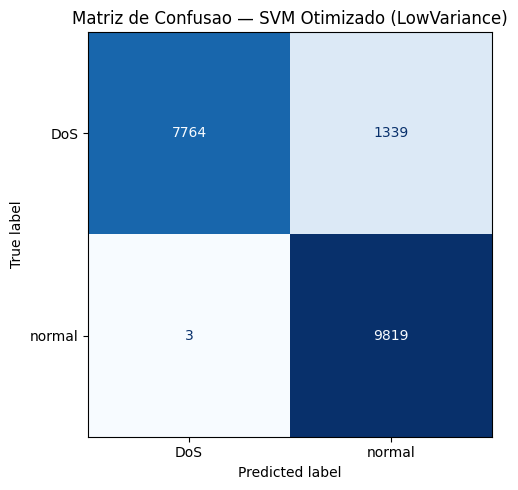

Matriz salva em: ../reports/reports_ensemble_v2/svm_confusion_matrix.png


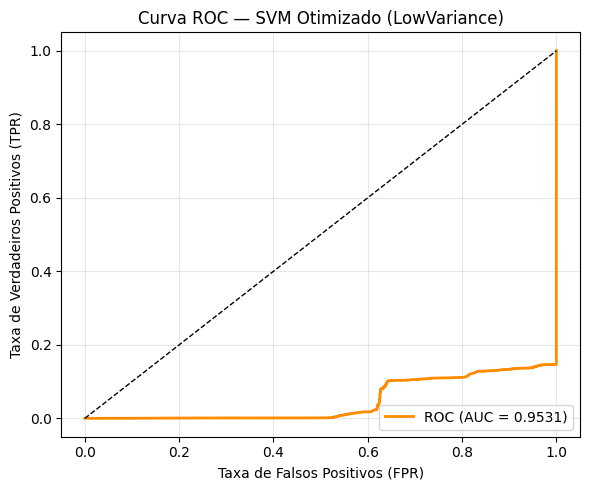

ROC salva em: ../reports/reports_ensemble_v2/svm_roc_curve.png


In [10]:
# Treinar modelo final
final_params = best_params.copy()
final_params['probability'] = True
final_params['random_state'] = RANDOM_STATE

svm_best = SVC(**final_params)

fit_start = time.perf_counter()
svm_best.fit(X_train_scaled, y_train)
tempo_fit = time.perf_counter() - fit_start

result_best = evaluate_svm(svm_best, X_test_scaled, y_test, compute_proba=True)
m = result_best['metrics']

append_timing('modelo_final', modelo='SVM', n_features=len(LOWVARIANCE_FEATURES),
              tempo_fit_sec=tempo_fit, tempo_total_sec=tempo_fit + result_best['tempo_total_sec'])

print('=' * 60)
print('SVM OTIMIZADO')
print('=' * 60)
kernel_name = final_params.get('kernel', 'rbf')
print(f'  Kernel:    {kernel_name}')
print(f'  C:         {final_params.get("C", 1.0)}')
print(f'  Gamma:     {final_params.get("gamma", "scale")}')
if 'degree' in final_params:
    print(f'  Degree:    {final_params["degree"]}')
if 'coef0' in final_params:
    print(f'  Coef0:     {final_params["coef0"]}')
print(f'\n--- Metricas no teste ---')
print(f'  Accuracy:  {m["accuracy"]:.4f}')
print(f'  Precision: {m["precision"]:.4f}')
print(f'  Recall:    {m["recall"]:.4f}')
print(f'  F1 Score:  {m["f1"]:.4f}')
print(f'  Log Loss:  {m["log_loss"]:.4f}')
print(f'  FP: {result_best["fp_per_class"]}')
print(f'  FN: {result_best["fn_per_class"]}')
print(classification_report(y_test, result_best['predictions']))

# Matriz de confusao
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, result_best['predictions'],
    ax=ax, cmap='Blues', colorbar=False,
    values_format='d'
)
ax.set_title('Matriz de Confusao — SVM Otimizado (LowVariance)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Matriz salva em: {REPORTS_DIR / "svm_confusion_matrix.png"}')

# Curva ROC
y_score = svm_best.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label='DoS')
roc_auc = roc_auc_score(y_test, y_score)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC — SVM Otimizado (LowVariance)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svm_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC salva em: {REPORTS_DIR / "svm_roc_curve.png"}')

## 10. Salvar Artefatos

Persiste modelo, metadados e tabela comparativa em disco.

In [11]:
from sklearn.pipeline import Pipeline

# Pipeline completo (scaler + SVM) para API de inferencia
pipeline = Pipeline([('scaler', scaler), ('svm', svm_best)])
joblib.dump(pipeline, API_MODELS_DIR / f'{API_MODEL_NAME}.pkl')

# Dataset de teste no padrao da API
test_df_out.to_csv(API_DATASETS_TEST_DIR / f'test_{API_MODEL_NAME}.csv', index=False)

# Salvar modelo raw
joblib.dump(svm_best, MODELS_DIR / 'best_svm_lowvariance.pkl')

# Metadados
model_info = {
    'modelo': 'SVC',
    'features': LOWVARIANCE_FEATURES,
    'n_features': len(LOWVARIANCE_FEATURES),
    'best_params': {k: v for k, v in final_params.items()
                    if k not in ('probability', 'random_state')},
    'baseline_metrics': {k: float(v) for k, v in result_base['metrics'].items()},
    'optimized_metrics': {k: float(v) for k, v in result_best['metrics'].items()},
    'optuna_method': 'hold_out',
    'optuna_n_trials': N_TRIALS_FAST,
    'optuna_best_f1_val': float(study.best_value),
    'optuna_elapsed_sec': opt_elapsed,
    'test_accuracy': float(m['accuracy']),
    'test_f1': float(m['f1']),
    'test_roc_auc': float(roc_auc),
    'random_state': RANDOM_STATE,
    'experiment_timestamp': pd.Timestamp.now().isoformat(),
}

with open(MODELS_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# Tabela comparativa
comparison = pd.DataFrame([
    {
        'modelo': 'SVM Baseline (rbf, C=1.0)',
        'accuracy': result_base['metrics']['accuracy'],
        'precision': result_base['metrics']['precision'],
        'recall': result_base['metrics']['recall'],
        'f1': result_base['metrics']['f1'],
        'log_loss': result_base['metrics']['log_loss'],
    },
    {
        'modelo': f'SVM Otimizado ({kernel_name})',
        'accuracy': m['accuracy'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'log_loss': m['log_loss'],
    },
])
comparison.to_csv(REPORTS_DIR / 'svm_results.csv', index=False)

print('=' * 60)
print('ARTEFATOS SALVOS')
print('=' * 60)
print(f'\n--- API Inference (Pipeline + dataset) ---')
print(f'  Pipeline: {API_MODELS_DIR / f"{API_MODEL_NAME}.pkl"}')
print(f'  Dataset:  {API_DATASETS_TEST_DIR / f"test_{API_MODEL_NAME}.csv"}')
print(f'\n--- Modelo e Scaler (raw) ---')
print(f'  Modelo: {MODELS_DIR / "best_svm_lowvariance.pkl"}')
print(f'  Scaler: {MODELS_DIR / "scaler.pkl"}')
print(f'  Info:   {MODELS_DIR / "model_info.json"}')
print(f'\n--- Datasets (12 features + type, imputados, NAO escalados) ---')
print(f'  Completo: {DATA_PROCESSED / "lowvariance_complete.csv"}')
print(f'  Treino:   {DATA_PROCESSED / "lowvariance_train_raw.csv"}')
print(f'  Teste:    {DATA_PROCESSED / "lowvariance_test_raw.csv"}')
print(f'\n--- Relatorios ---')
print(f'  Metricas:      {REPORTS_DIR / "svm_results.csv"}')
print(f'  Matriz conf:   {REPORTS_DIR / "svm_confusion_matrix.png"}')
print(f'  Curva ROC:     {REPORTS_DIR / "svm_roc_curve.png"}')
print(f'  Hist. Optuna:  {REPORTS_DIR / "svm_optuna_history.png"}')

ARTEFATOS SALVOS

--- API Inference (Pipeline + dataset) ---
  Pipeline: ../api_inference/models/optuna_by_selector_lowvariance_svm.pkl
  Dataset:  ../api_inference/datasets/test/test_optuna_by_selector_lowvariance_svm.csv

--- Modelo e Scaler (raw) ---
  Modelo: ../models/models_ensemble_v2/svm/best_svm_lowvariance.pkl
  Scaler: ../models/models_ensemble_v2/svm/scaler.pkl
  Info:   ../models/models_ensemble_v2/svm/model_info.json

--- Datasets (12 features + type, imputados, NAO escalados) ---
  Completo: ../data/processed/feature_sets/lowvariance_complete.csv
  Treino:   ../data/processed/feature_sets/lowvariance_train_raw.csv
  Teste:    ../data/processed/feature_sets/lowvariance_test_raw.csv

--- Relatorios ---
  Metricas:      ../reports/reports_ensemble_v2/svm_results.csv
  Matriz conf:   ../reports/reports_ensemble_v2/svm_confusion_matrix.png
  Curva ROC:     ../reports/reports_ensemble_v2/svm_roc_curve.png
  Hist. Optuna:  ../reports/reports_ensemble_v2/svm_optuna_history.png


## 11. Resumo Final

In [12]:
print('=' * 60)
print('RESUMO — SVM + LOWVARIANCE')
print('=' * 60)
print(f'\nDataset:   94.625 amostras, {len(LOWVARIANCE_FEATURES)} features')
print(f'Split:     80/20 estratificado')
print(f'  Treino:  {X_train.shape[0]} amostras')
print(f'  Teste:   {X_test.shape[0]} amostras')

print(f'\n{"Metrica":<20} {"Baseline":<15} {"Otimizado":<15}')
print('-' * 50)
base_m = result_base['metrics']
best_m = result_best['metrics']
print(f'{"Accuracy":<20} {base_m["accuracy"]:<15.4f} {best_m["accuracy"]:<15.4f}')
print(f'{"Precision":<20} {base_m["precision"]:<15.4f} {best_m["precision"]:<15.4f}')
print(f'{"Recall":<20} {base_m["recall"]:<15.4f} {best_m["recall"]:<15.4f}')
print(f'{"F1 Score":<20} {base_m["f1"]:<15.4f} {best_m["f1"]:<15.4f}')
print(f'{"Log Loss":<20} {base_m["log_loss"]:<15.4f} {best_m["log_loss"]:<15.4f}')

print(f'\nMelhores hiperparametros:')
for k, v in final_params.items():
    if k not in ('probability', 'random_state'):
        print(f'  {k}: {v}')

print(f'\nROC AUC no teste: {roc_auc:.4f}')
print(f'\n--- Optuna ---')
print(f'  Metodo:  svm_hold_out (hold-out 80/20)')
print(f'  Trials:  {N_TRIALS_FAST}')
print(f'  Tempo:   {opt_elapsed:.2f}s')
print(f'\n--- Alternativa robusta ---')
print(f'  Para ativar svm_2_fold:')
print(f'    1. Comente a celula "Optuna -- svm_hold_out"')
print(f'    2. Descomente a celula "svm_2_fold"')
print(f'    3. Reexecute')
print(f'  ~50x mais lento, 50 trials, 2-fold CV')
print(f'\n--- Caminhos dos artefatos ---')
print(f'  Pipeline (API): {API_MODELS_DIR / f"{API_MODEL_NAME}.pkl"}')
print(f'  Dataset (API):  {API_DATASETS_TEST_DIR / f"test_{API_MODEL_NAME}.csv"}')
print(f'  Modelo raw:     {MODELS_DIR / "best_svm_lowvariance.pkl"}')
print(f'  Dataset completo: {DATA_PROCESSED / "lowvariance_complete.csv"}')
print(f'  Dataset treino:   {DATA_PROCESSED / "lowvariance_train_raw.csv"}')
print(f'  Dataset teste:    {DATA_PROCESSED / "lowvariance_test_raw.csv"}')
print(f'  Relatorio:        {REPORTS_DIR / "svm_results.csv"}')

RESUMO — SVM + LOWVARIANCE

Dataset:   94.625 amostras, 12 features
Split:     80/20 estratificado
  Treino:  75700 amostras
  Teste:   18925 amostras

Metrica              Baseline        Otimizado      
--------------------------------------------------
Accuracy             0.9278          0.9291         
Precision            0.9359          0.9375         
Recall               0.9278          0.9291         
F1 Score             0.9273          0.9285         
Log Loss             0.2226          0.2179         

Melhores hiperparametros:
  C: 3.836519337616777
  gamma: 0.5304456376446945

ROC AUC no teste: 0.9531

--- Optuna ---
  Metodo:  svm_hold_out (hold-out 80/20)
  Trials:  12
  Tempo:   92.25s

--- Alternativa robusta ---
  Para ativar svm_2_fold:
    1. Comente a celula "Optuna -- svm_hold_out"
    2. Descomente a celula "svm_2_fold"
    3. Reexecute
  ~50x mais lento, 50 trials, 2-fold CV

--- Caminhos dos artefatos ---
  Pipeline (API): ../api_inference/models/optuna_by_s